In [46]:
import pandas as pd

df = pd.read_csv("combined_pc_hardware_cleaned.csv")
df.head()

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.isnull().sum()




CPU            10360
category           0
GPU            11200
motherBoard    10360
Ram            10360
SSD             9160
PowerSupply    10680
cabinates       8680
price              3
dtype: int64

In [47]:
df.fillna(0, inplace=True)

df.columns = df.columns.str.lower().str.strip()

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df[df["price"] > 0]

cpu_df = df[df["category"] == "CPU"]
gpu_df = df[df["category"] == "GPU"]
ram_df = df[df["category"] == "RAM"]

features = ["category", "price"]
df_ml = df[features]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_ml["category_encoded"] = le.fit_transform(df_ml["category"])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_ml["price_scaled"] = scaler.fit_transform(df_ml[["price"]])

df_ml.to_csv("preprocessed_pc_hardware.csv", index=False)






C:\Users\nagul\AppData\Local\Temp\ipykernel_16240\3471695770.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["category_encoded"] = le.fit_transform(df_ml["category"])
C:\Users\nagul\AppData\Local\Temp\ipykernel_16240\3471695770.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["price_scaled"] = scaler.fit_transform(df_ml[["price"]])


In [48]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11797 entries, 0 to 11799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cpu          11797 non-null  object 
 1   category     11797 non-null  object 
 2   gpu          11797 non-null  object 
 3   motherboard  11797 non-null  object 
 4   ram          11797 non-null  object 
 5   ssd          11797 non-null  object 
 6   powersupply  11797 non-null  object 
 7   cabinates    11797 non-null  object 
 8   price        11797 non-null  float64
dtypes: float64(1), object(8)
memory usage: 921.6+ KB


In [49]:
df["category"].value_counts()


category
cabinates      3120
StorageSSD     2640
CPU            1440
MotherBoard    1440
RAM            1437
PowerSupply    1120
GPU             600
Name: count, dtype: int64

In [50]:
df["price"].describe()


count     11797.000000
mean       7859.386115
std       16489.394744
min         129.000000
25%        1499.000000
50%        2325.000000
75%        6819.000000
max      207999.000000
Name: price, dtype: float64

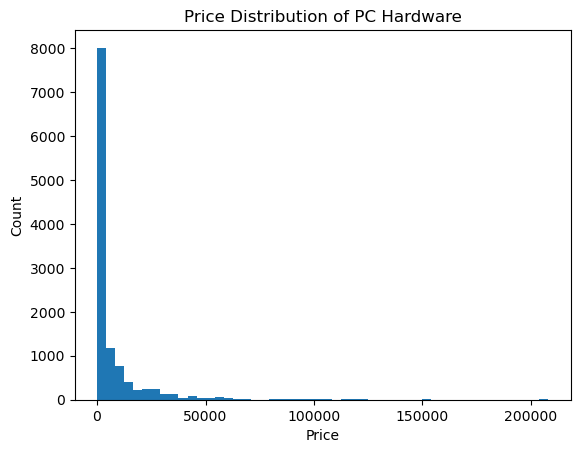

In [51]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution of PC Hardware")
plt.show()


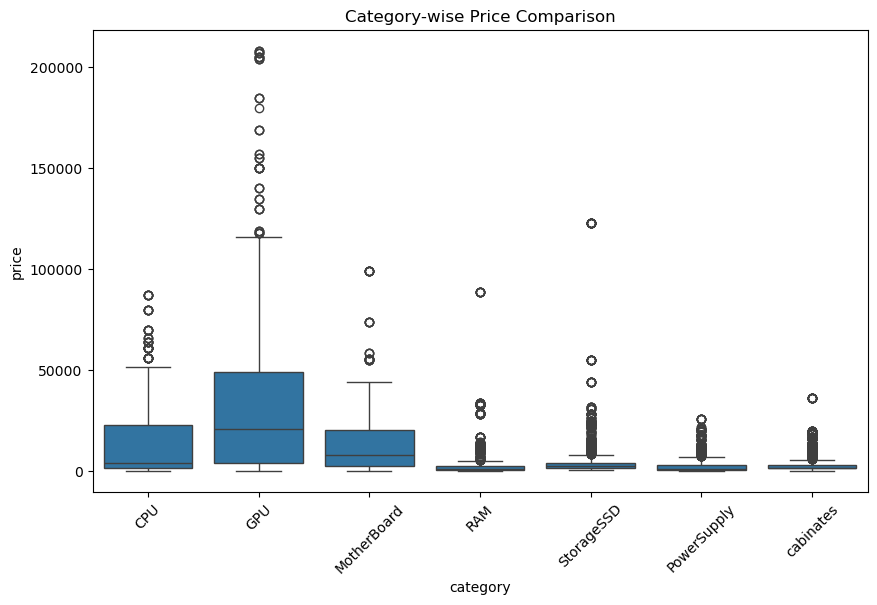

In [52]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="category", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Category-wise Price Comparison")
plt.show()


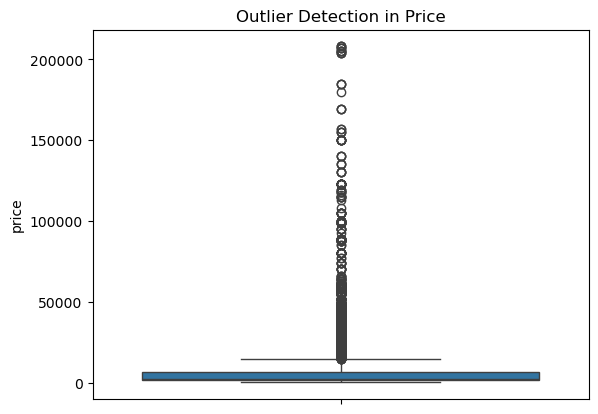

In [53]:
sns.boxplot(y=df["price"])
plt.title("Outlier Detection in Price")
plt.show()


In [54]:
df.isnull().sum().sort_values(ascending=False)


cpu            0
category       0
gpu            0
motherboard    0
ram            0
ssd            0
powersupply    0
cabinates      0
price          0
dtype: int64

In [55]:
df.sort_values(by="price", ascending=False).head(10)


,cpu,category,gpu,motherboard,ram,ssd,powersupply,cabinates,price
1674,0,GPU,MSI NVIDIA RTX 3090 Ti GAMING X TRIO 24G 24 GB...,0,0,0,0,0,207999.0
1794,0,GPU,MSI NVIDIA RTX 3090 Ti GAMING X TRIO 24G 24 GB...,0,0,0,0,0,207999.0
1954,0,GPU,MSI NVIDIA RTX 3090 Ti GAMING X TRIO 24G 24 GB...,0,0,0,0,0,207999.0
1946,0,GPU,Inno3D NVIDIA RTX 3090 TI 24GB X3 OC 24 GB GDD...,0,0,0,0,0,206999.0
1786,0,GPU,Inno3D NVIDIA RTX 3090 TI 24GB X3 OC 24 GB GDD...,0,0,0,0,0,206999.0
1666,0,GPU,Inno3D NVIDIA RTX 3090 TI 24GB X3 OC 24 GB GDD...,0,0,0,0,0,206999.0
1613,0,GPU,MSI NVIDIA RTX 3090 VENTUS 24 GB GDDR6X Graphi...,0,0,0,0,0,204999.0
1733,0,GPU,MSI NVIDIA RTX 3090 VENTUS 24 GB GDDR6X Graphi...,0,0,0,0,0,204999.0
1533,0,GPU,MSI NVIDIA RTX 3090 VENTUS 24 GB GDDR6X Graphi...,0,0,0,0,0,204999.0
1893,0,GPU,MSI NVIDIA RTX 3090 VENTUS 24 GB GDDR6X Graphi...,0,0,0,0,0,204999.0


In [56]:
print(df.columns)
features = ["price"]
X = df[features]



Index(['cpu', 'category', 'gpu', 'motherboard', 'ram', 'ssd', 'powersupply',
       'cabinates', 'price'],
      dtype='object')


In [57]:
import pandas as pd

# Load dataset
df = pd.read_csv("combined_pc_hardware_cleaned.csv")

# Fill missing values
df = df.fillna("Unknown")

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["category_encoded"] = le.fit_transform(df["category"])

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [60]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)

In [61]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

knn.fit(X_scaled)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [62]:
def recommend_hardware(index):
    
    distances, indices = knn.kneighbors([X_scaled[index]])
    
    print("Recommended Hardware:\n")
    
    for i in indices[0]:
        print(df.iloc[i]["product_name"], "-", df.iloc[i]["price"])
        
        

In [63]:
df["product_name"] = (
    df["CPU"]
    .fillna(df["GPU"])
    .fillna(df["Ram"])
    .fillna(df["SSD"])
    .fillna(df["PowerSupply"])
    .fillna(df["cabinates"])
)


In [66]:
df["product_name"] = (
    df["CPU"]
    .fillna(df["GPU"])
    .fillna(df["Ram"])
    .fillna(df["SSD"])
    .fillna(df["PowerSupply"])
    .fillna(df["cabinates"])
)

df["product_name"] = df["product_name"].fillna("Unknown")

In [67]:
df = df[df["product_name"] != "Unknown"]

In [68]:
def recommend_hardware(index):

    distances, indices = knn.kneighbors([X_scaled[index]])

    print("Recommended Hardware:\n")

    for i in indices[0]:
        name = df.iloc[i]["product_name"]
        price = df.iloc[i]["price"]
        category = df.iloc[i]["category"]

        print(f"{name} | {category} | ₹{price}")

In [70]:
recommend_hardware(0)
recommend_hardware(50)
recommend_hardware(100)
recommend_hardware(200)

Recommended Hardware:



IndexError: single positional indexer is out-of-bounds

In [1]:
# PC HARDWARE RECOMMENDATION SYSTEM
# Hybrid Approach: KNN + Cosine Similarity

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("combined_pc_hardware_cleaned.csv")

# -----------------------------
# Create product_name column
# -----------------------------
df["product_name"] = (
    df["CPU"]
    .fillna(df["GPU"])
    .fillna(df["Ram"])
    .fillna(df["SSD"])
    .fillna(df["PowerSupply"])
    .fillna(df["cabinates"])
)

# Remove rows with no name
df = df.dropna(subset=["product_name"])

# Reset index
df = df.reset_index(drop=True)

# -----------------------------
# Fill missing values
# -----------------------------
df["category"] = df["category"].fillna("Unknown")
df["price"] = df["price"].fillna(df["price"].median())

# -----------------------------
# Encode category
# -----------------------------
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])

# -----------------------------
# Feature Selection
# -----------------------------
features = ["price", "category_encoded"]
X = df[features]

# -----------------------------
# Scale Features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Build KNN Model
# -----------------------------
knn = NearestNeighbors(n_neighbors=5, metric="cosine")
knn.fit(X_scaled)

# -----------------------------
# Recommendation Function
# -----------------------------
def recommend_hardware(index):

    if index >= len(df):
        print("Index out of range")
        return

    distances, indices = knn.kneighbors([X_scaled[index]])

    print("\nSelected Hardware:")
    print(df.iloc[index]["product_name"], "|", df.iloc[index]["category"], "| ₹", df.iloc[index]["price"])

    print("\nRecommended Hardware:\n")

    for i in indices[0]:
        name = df.iloc[i]["product_name"]
        category = df.iloc[i]["category"]
        price = df.iloc[i]["price"]

        print(f"{name} | {category} | ₹{price}")

# -----------------------------
# Test the Recommendation System
# -----------------------------
recommend_hardware(10)


Selected Hardware:
amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz Upto 4.4 Ghz AM4 Socket 8 Cores 16 Threads 4 MB L2 32 MB L3 Desktop Processor | CPU | ₹ 27999.0

Recommended Hardware:

amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz Upto 4.4 Ghz AM4 Socket 8 Cores 16 Threads 4 MB L2 32 MB L3 Desktop Processor | CPU | ₹27999.0
amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz Upto 4.4 Ghz AM4 Socket 8 Cores 16 Threads 4 MB L2 32 MB L3 Desktop Processor | CPU | ₹27999.0
amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz Upto 4.4 Ghz AM4 Socket 8 Cores 16 Threads 4 MB L2 32 MB L3 Desktop Processor | CPU | ₹27999.0
amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz Upto 4.4 Ghz AM4 Socket 8 Cores 16 Threads 4 MB L2 32 MB L3 Desktop Processor | CPU | ₹27999.0
amd Ryzen 7 3700X with Wraith Prism & RGB LED Cooler (100-100000071BOX) 3.6 Ghz 

In [2]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors

st.set_page_config(page_title="PC Hardware Recommender", layout="wide")

st.title("💻 PC Hardware Recommendation System")
st.write("Hybrid Model: **KNN + Cosine Similarity**")

# -----------------------------
# Load Dataset
# -----------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("combined_pc_hardware_cleaned.csv")

    df["product_name"] = (
        df["CPU"]
        .fillna(df["GPU"])
        .fillna(df["Ram"])
        .fillna(df["SSD"])
        .fillna(df["PowerSupply"])
        .fillna(df["cabinates"])
    )

    df = df.dropna(subset=["product_name"])
    df = df.reset_index(drop=True)

    df["category"] = df["category"].fillna("Unknown")
    df["price"] = df["price"].fillna(df["price"].median())

    return df

df = load_data()

# -----------------------------
# Encode category
# -----------------------------
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])

# -----------------------------
# Feature Selection
# -----------------------------
features = ["price", "category_encoded"]
X = df[features]

# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# KNN Model
# -----------------------------
knn = NearestNeighbors(n_neighbors=5, metric="cosine")
knn.fit(X_scaled)

# -----------------------------
# Sidebar Filters
# -----------------------------
st.sidebar.header("🔎 Search Hardware")

hardware_list = df["product_name"].unique()
selected_hardware = st.sidebar.selectbox("Select Hardware", hardware_list)

# -----------------------------
# Recommendation Logic
# -----------------------------
def recommend_hardware(name):

    index = df[df["product_name"] == name].index[0]

    distances, indices = knn.kneighbors([X_scaled[index]])

    recommendations = df.iloc[indices[0]][["product_name", "category", "price"]]

    return recommendations

# -----------------------------
# Button
# -----------------------------
if st.sidebar.button("Recommend Similar Hardware"):

    recs = recommend_hardware(selected_hardware)

    st.subheader("🔧 Selected Hardware")
    selected_row = df[df["product_name"] == selected_hardware][["product_name","category","price"]]
    st.dataframe(selected_row)

    st.subheader("⭐ Recommended Hardware")
    st.dataframe(recs)

# -----------------------------
# Dataset Preview
# -----------------------------
st.subheader("📊 Dataset Preview")
st.dataframe(df.head(20))

2026-03-11 22:48:09.567 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:48:09.569 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:48:10.198 
  command:

    streamlit run C:\Users\nagul\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-11 22:48:10.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:48:10.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:48:10.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:48:10.201 Thread 'MainThread': missing ScriptRunContext! This warning can b

DeltaGenerator()